In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# Constants
CONV_KM_TO_INV_EV = 5.067731e9  # Conversion factor from km to inverse eV
VCC_EARTH_CRUST = 7.6e-14  # Matter potential in eV

# Define mixing matrix elements
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

# Define Hamiltonians
def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])  # Mass squared differences
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    H_vacuum = U @ m2_diag @ np.conj(U.T) / (2 * E)
    return H_vacuum

def hamiltonian_4nu_matter(H_vacuum, E, VCC):
    H_matter = H_vacuum + np.diag([VCC, 0, 0, 0])
    return H_matter

# Compute probabilities
def probabilities_4nu_vacuum(H_vacuum, baseline):
    H_t = -1j * H_vacuum * baseline
    S = expm(H_t)  # Evolution operator
    Pmm = np.abs(S[1, 1])**2  # Muon neutrino survival probability
    Pme = np.abs(S[1, 0])**2  # Muon to electron
    Pmt = np.abs(S[1, 2])**2  # Muon to tau
    Pms = np.abs(S[1, 3])**2  # Muon to sterile
    return Pmm, Pme, Pmt, Pms

def probabilities_4nu_matter(H_matter, baseline):
    H_t = -1j * H_matter * baseline
    S = expm(H_t)  # Evolution operator
    Pmm = np.abs(S[1, 1])**2  # Muon neutrino survival probability
    Pme = np.abs(S[1, 0])**2  # Muon to electron
    Pmt = np.abs(S[1, 2])**2  # Muon to tau
    Pms = np.abs(S[1, 3])**2  # Muon to sterile
    return Pmm, Pme, Pmt, Pms

# Compute oscillation probabilities
def compute_probabilities(baseline, energy_values, matter = False):
    Prob_mm, Prob_me, Prob_mt, Prob_ms = [], [], [], []
    for E in energy_values:
        #Compute vacuum hamiltonian
        H_vacuum = hamiltonian_4nu_vacuum(
            theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E
        )

        if matter:
          #Compute matter hamiltonian if matter effects included
          H_matter = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
          Pmm, Pme, Pmt, Pms = probabilities_4nu_matter(H_matter, baseline * CONV_KM_TO_INV_EV)


        else:
          #Vacuum oscillations if no matter effects
          Pmm, Pme, Pmt, Pms = probabilities_4nu_vacuum(H_vacuum, baseline * CONV_KM_TO_INV_EV)



        Prob_mm.append(Pmm)
        Prob_me.append(Pme)
        Prob_mt.append(Pmt)
        Prob_ms.append(Pms)
    return np.array(Prob_mm), np.array(Prob_me), np.array(Prob_mt), np.array(Prob_ms)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Oscillation Parameters
theta12, theta13, theta23 = np.radians([33.82, 8.61, 48.3])  # Standard angles
theta14, theta24, theta34 = np.radians([10.0, 5.0, 2.0])  # Sterile neutrino angles
delta13, delta14 = np.radians([0, 0])  # CP violation phases
D21, D31, D41 = [7.39e-5, 2.525e-3, 1.0]  # Mass squared differences in eV^2

# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

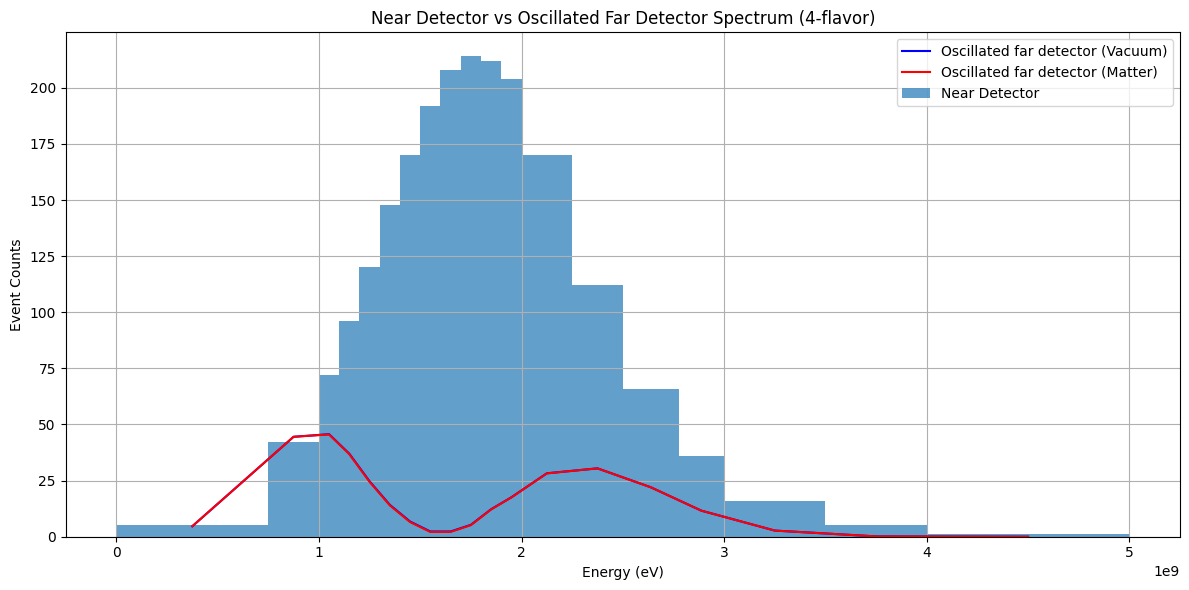

In [14]:
#Compute oscillation probabilities at the far detector
prob_mm_far_vac, prob_me_far_vac, prob_mt_far_vac, prob_ms_far_vac = compute_probabilities(Length_far, bin_centers, matter = False)
prob_mm_far_matter, prob_me_far_matter, prob_mt_far_matter, prob_ms_far_matter = compute_probabilities(Length_far, bin_centers, matter = True)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd_vac = gaussian(bin_centers, *popt_nd) * prob_mm_far_vac / np.max(prob_mm_far_vac)
oscillated_fd_matter = gaussian(bin_centers, *popt_nd) * prob_mm_far_matter / np.max(prob_mm_far_matter)

plt.figure(figsize = (12, 6))
plt.bar(bin_centers, counts_nd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Near Detector')
plt.plot(bin_centers, oscillated_fd_vac, 'b-', label = 'Oscillated far detector (Vacuum)')
plt.plot(bin_centers, oscillated_fd_matter, 'r-', label = 'Oscillated far detector (Matter)')

#Labels and Titles
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (4-flavor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

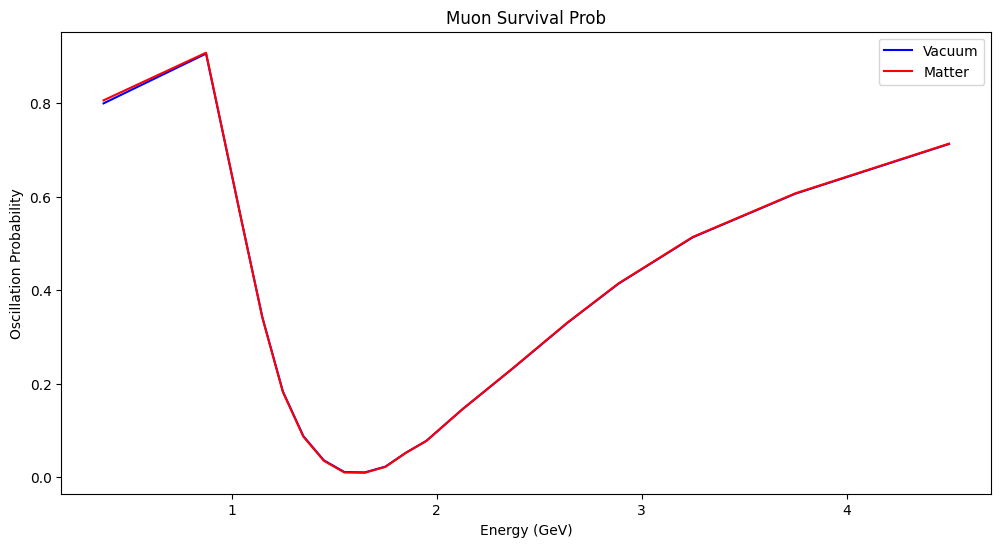

In [17]:
plt.figure(figsize = (12,6))

plt.plot(bin_centers / 1e9, prob_mm_far_vac, 'b-', label = 'Vacuum')
plt.plot(bin_centers / 1e9, prob_mm_far_matter, 'r-', label = 'Matter')

plt.xlabel('Energy (GeV)')
plt.ylabel('Oscillation Probability')
plt.title('Muon Survival Prob')
plt.legend()
plt.show()

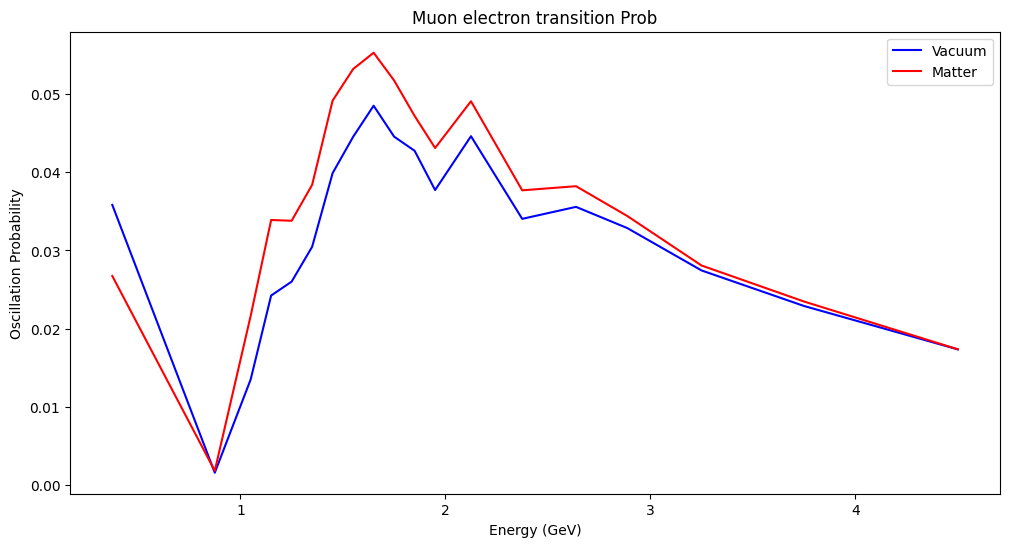

In [19]:
plt.figure(figsize = (12,6))

plt.plot(bin_centers / 1e9, prob_me_far_vac, 'b-', label = 'Vacuum')
plt.plot(bin_centers / 1e9, prob_me_far_matter, 'r-', label = 'Matter')

plt.xlabel('Energy (GeV)')
plt.ylabel('Oscillation Probability')
plt.title('Muon electron transition Prob')
plt.legend()
plt.show()

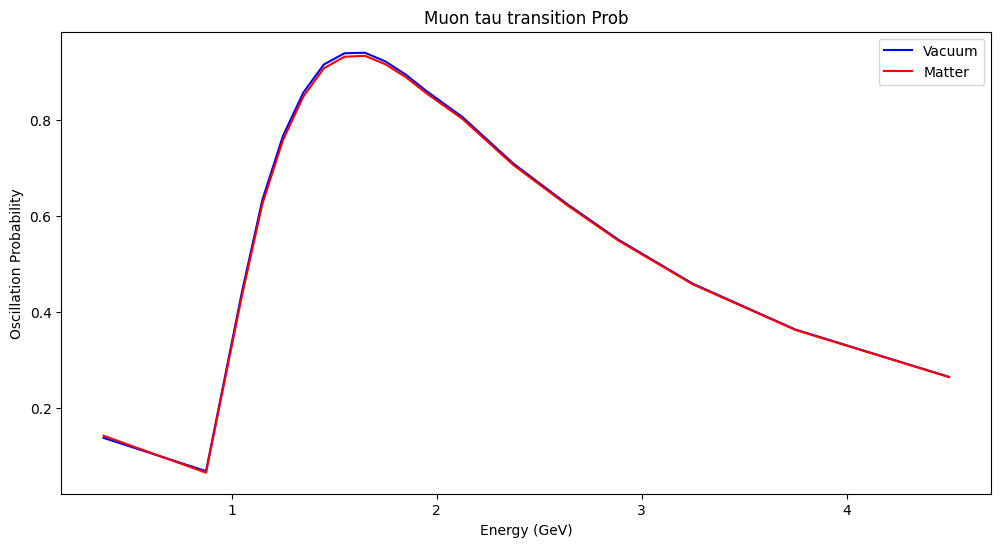

In [20]:
plt.figure(figsize = (12,6))

plt.plot(bin_centers / 1e9, prob_mt_far_vac, 'b-', label = 'Vacuum')
plt.plot(bin_centers / 1e9, prob_mt_far_matter, 'r-', label = 'Matter')

plt.xlabel('Energy (GeV)')
plt.ylabel('Oscillation Probability')
plt.title('Muon tau transition Prob')
plt.legend()
plt.show()

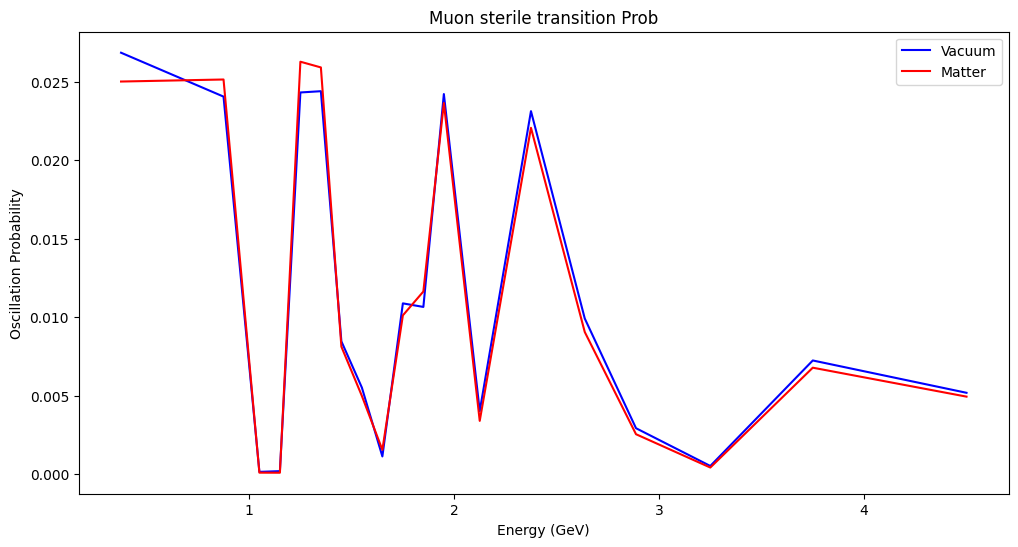

In [21]:
plt.figure(figsize = (12,6))

plt.plot(bin_centers / 1e9, prob_ms_far_vac, 'b-', label = 'Vacuum')
plt.plot(bin_centers / 1e9, prob_ms_far_matter, 'r-', label = 'Matter')

plt.xlabel('Energy (GeV)')
plt.ylabel('Oscillation Probability')
plt.title('Muon sterile transition Prob')
plt.legend()
plt.show()

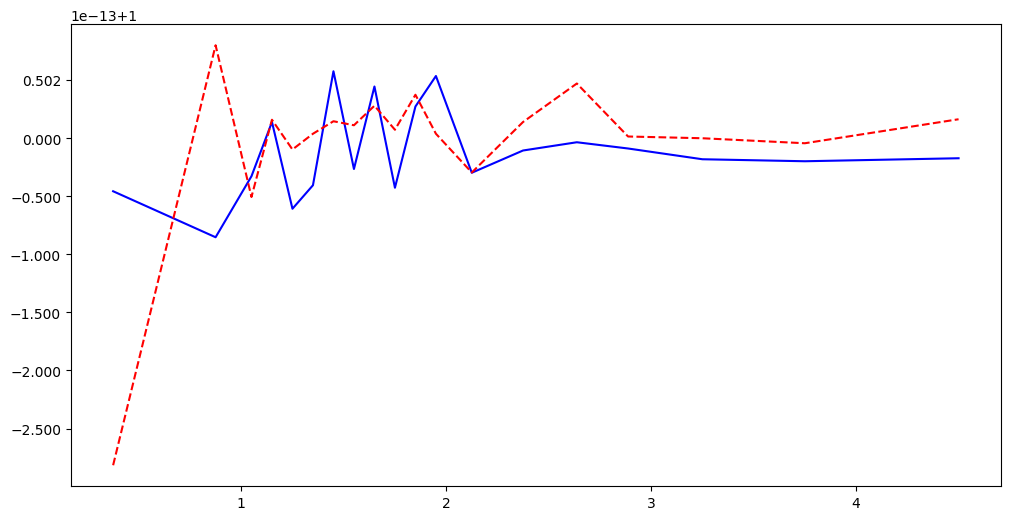

In [23]:
total_prob_vac = prob_mm_far_vac + prob_me_far_vac + prob_mt_far_vac + prob_ms_far_vac
total_prob_matter = prob_mm_far_matter + prob_me_far_matter + prob_mt_far_matter + prob_ms_far_matter

plt.figure(figsize = (12,6))
plt.plot(bin_centers / 1e9, total_prob_vac, 'b-', label = 'Total Probability (Vacuum)')
plt.plot(bin_centers / 1e9, total_prob_matter, 'r--', label = 'Total Probability (Matter)')
